# Parameter Study: PnL and Spread

Three experiments, each varying one parameter. Per experiment:
- **PnL figure**: realized profit distribution (violin) with worst-case loss bound as a dashed floor
- **Spread figure**: mean bid-ask spread over $T=500$ steps; dashed lines mark the analytic spread at $q=0$

All figures saved as PDF and PNG.

In [5]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm

sys.path.insert(0, '.')
from MarketSim.marketmaker import LMSR, CFMM
from MarketSim.market import Market

# ── Paper-quality rcParams ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
})

N_RUNS = 100
T = 500
NOISE_RATIO = 0.5
CONFIDENCE = 0.3

C_LMSR = '#2166ac'
C_CFMM  = '#d6604d'

def make_true_p(n):
    p = np.ones(n) / n
    p[0] += 0.2
    return p / p.sum()

def run_experiment(param_vals, make_lmsr, make_cfmm, n_fn, lmsr_bound, cfmm_bound):
    """
    For each param value, run N_RUNS simulations of both AMMs.
    make_lmsr(pv), make_cfmm(pv) -> MarketMaker instances.
    n_fn(pv) -> number of outcomes for that param value.
    lmsr_bound(pv), cfmm_bound(pv) -> theoretical worst-case loss.
    Returns dict keyed by param value.
    """
    data = {}
    for pv in param_vals:
        n = n_fn(pv)
        true_p = make_true_p(n)
        r0 = np.zeros(n); r0[0] = 1.0
        lpnl, cpnl, lsp, csp = [], [], [], []
        for _ in range(N_RUNS):
            mm = make_lmsr(pv)
            _, sh, _, r = Market(mm, T, true_p, NOISE_RATIO,
                                 agent_confidence=CONFIDENCE).run()
            lpnl.append(r); lsp.append(sh)
            mm = make_cfmm(pv)
            _, sh, _, r = Market(mm, T, true_p, NOISE_RATIO,
                                 agent_confidence=CONFIDENCE).run()
            cpnl.append(r); csp.append(sh)
        data[pv] = dict(
            lmsr_pnl=np.array(lpnl),  cfmm_pnl=np.array(cpnl),
            lmsr_sp=np.array(lsp),    cfmm_sp=np.array(csp),    # (N_RUNS, T)
            lmsr_sp0=make_lmsr(pv).get_spread(r0),
            cfmm_sp0=make_cfmm(pv).get_spread(r0),
            lmsr_bound=lmsr_bound(pv), cfmm_bound=cfmm_bound(pv),
        )
        print(f'  pv={pv}: LMSR med={np.median(lpnl):+.1f}, '
              f'CFMM med={np.median(cpnl):+.1f},  '
              f'bounds: LMSR={lmsr_bound(pv):.1f}, CFMM={cfmm_bound(pv):.1f}')
    return data

def _style_violin(parts, color):
    for b in parts['bodies']:
        b.set_facecolor(color); b.set_alpha(0.45); b.set_edgecolor('none')
    parts['cmedians'].set_color(color); parts['cmedians'].set_linewidth(2.0)

def plot_pnl_paired(data, param_vals, tick_labels, x_label, save_name):
    """
    One violin pair (LMSR, CFMM) per parameter value.
    Dashed horizontal = worst-case loss floor for that violin.
    """
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    gap, hw = 0.28, 0.18
    spacing = 1.4
    centers = np.arange(len(param_vals), dtype=float) * spacing

    for i, pv in enumerate(param_vals):
        d = data[pv]; c = centers[i]
        vl = ax.violinplot([d['lmsr_pnl']], [c - gap/2], widths=0.32,
                           showmedians=True, showextrema=False)
        _style_violin(vl, C_LMSR)
        vc = ax.violinplot([d['cfmm_pnl']], [c + gap/2], widths=0.32,
                           showmedians=True, showextrema=False)
        _style_violin(vc, C_CFMM)
        ax.hlines(-d['lmsr_bound'], c-gap/2-hw, c-gap/2+hw,
                  colors=C_LMSR, linestyles='--', lw=1.5)
        ax.hlines(-d['cfmm_bound'], c+gap/2-hw, c+gap/2+hw,
                  colors=C_CFMM,  linestyles='--', lw=1.5)

    ax.axhline(0, color='#aaaaaa', lw=0.8, ls=':', zorder=0)
    ax.set_xticks(centers)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Realized PnL')
    ax.grid(True, axis='y', alpha=0.25)
    p1 = mpatches.Patch(facecolor=C_LMSR, alpha=0.55, label='LMSR')
    p2 = mpatches.Patch(facecolor=C_CFMM,  alpha=0.55, label='CFMM')
    p3 = plt.Line2D([0],[0], color='#555', ls='--', lw=1.5, label='Worst-case bound')
    ax.legend(handles=[p1, p2, p3], ncol=3, loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.savefig(f'{save_name}.png', bbox_inches='tight')
    plt.show()

def plot_spread_paired(data, param_vals, param_label, tick_vals, save_name):
    """
    Two panels: LMSR (left), CFMM (right). Lines colored by parameter value
    via sequential colormap; dashed lines = analytic spread at q=0.
    """
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 3.0))
    t_axis = np.arange(T)
    n_p = len(param_vals)
    shades = np.linspace(0.35, 0.90, n_p)

    for ax, key, cmap_name, title in [
        (axes[0], 'lmsr', 'Blues',   'LMSR'),
        (axes[1], 'cfmm', 'Oranges', 'CFMM'),
    ]:
        cmap = cm.get_cmap(cmap_name)
        for i, (pv, tv) in enumerate(zip(param_vals, tick_vals)):
            d = data[pv]
            ms = d[f'{key}_sp'].mean(axis=0)
            c  = cmap(shades[i])
            ax.plot(t_axis, ms, color=c, lw=1.5, label=f'${param_label}={tv}$')
            ax.axhline(d[f'{key}_sp0'], color=c, ls='--', lw=0.9, alpha=0.55)
        ax.set_xlabel('Step')
        ax.set_ylabel('Spread' if ax is axes[0] else '')
        ax.set_title(title)
        ax.legend(fontsize=8, ncol=1, loc='upper right', framealpha=0.9)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(f'{save_name}.pdf', bbox_inches='tight')
    plt.savefig(f'{save_name}.png', bbox_inches='tight')
    plt.show()

print('Setup complete.')

Setup complete.


---
## Vary $n$

Fix $b=50$, $k=b^n$ (normalized so both AMMs have equal initial depth). LMSR bound $= b\ln n$ grows; CFMM bound $= k^{1/n} = b = 50$ is constant.

In [6]:
N_VALS = [2, 4, 8, 16]
B1 = 50
print('Simulating: vary n')
data1 = run_experiment(
    N_VALS,
    make_lmsr  = lambda n: LMSR(n, b=B1),
    make_cfmm  = lambda n: CFMM(n, k_constant=B1**n),
    n_fn       = lambda n: n,
    lmsr_bound = lambda n: B1 * np.log(n),
    cfmm_bound = lambda n: float(B1),
)

Simulating: vary n
  pv=2: LMSR med=-5.6, CFMM med=-5.3,  bounds: LMSR=34.7, CFMM=50.0
  pv=4: LMSR med=+3.4, CFMM med=+3.1,  bounds: LMSR=69.3, CFMM=50.0
  pv=8: LMSR med=+2.4, CFMM med=+0.9,  bounds: LMSR=104.0, CFMM=50.0
  pv=16: LMSR med=+0.5, CFMM med=+0.5,  bounds: LMSR=138.6, CFMM=50.0


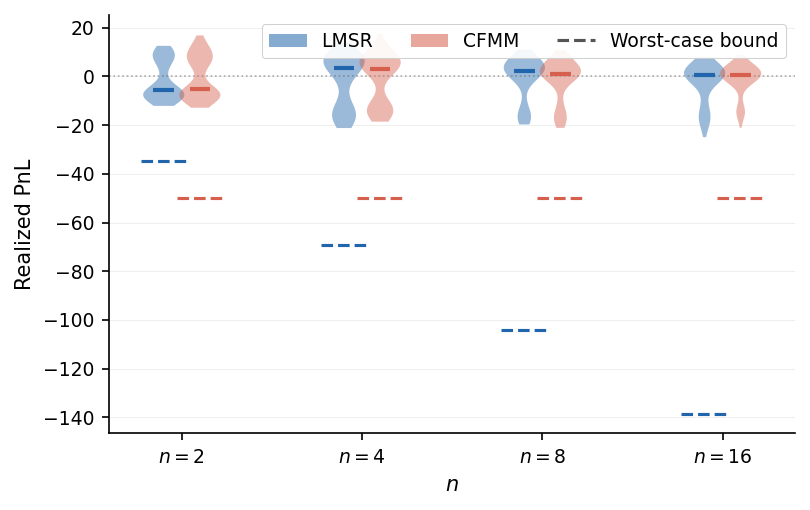

In [7]:
plot_pnl_paired(
    data1, N_VALS,
    tick_labels=[f'$n={n}$' for n in N_VALS],
    x_label='$n$',
    save_name='pnl_vary_n',
)

C:\Users\n8tew\AppData\Local\Temp\ipykernel_11400\1869584543.py:134: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


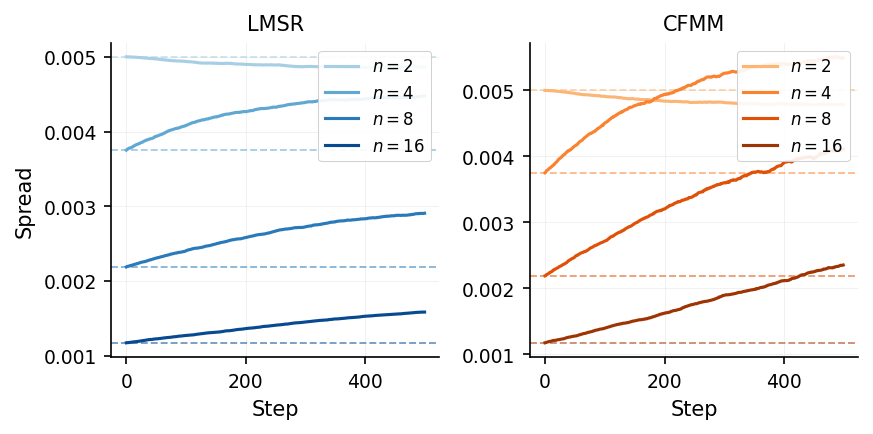

In [8]:
plot_spread_paired(
    data1, N_VALS,
    param_label='n', tick_vals=N_VALS,
    save_name='spread_vary_n',
)

---
## Vary $b$

Fix $n=2$, $k=b^2$. Both bounds scale linearly with $b$: LMSR $= b\ln 2$, CFMM $= b$.

In [9]:
B_VALS = [10, 25, 50, 100, 200]
N2 = 2
print('Simulating: vary b')
data2 = run_experiment(
    B_VALS,
    make_lmsr  = lambda b: LMSR(N2, b=b),
    make_cfmm  = lambda b: CFMM(N2, k_constant=b**N2),
    n_fn       = lambda b: N2,
    lmsr_bound = lambda b: b * np.log(N2),
    cfmm_bound = lambda b: float(b),
)

Simulating: vary b
  pv=10: LMSR med=-0.6, CFMM med=-0.7,  bounds: LMSR=6.9, CFMM=10.0
  pv=25: LMSR med=-1.3, CFMM med=-2.5,  bounds: LMSR=17.3, CFMM=25.0
  pv=50: LMSR med=-4.5, CFMM med=-3.6,  bounds: LMSR=34.7, CFMM=50.0
  pv=100: LMSR med=-10.9, CFMM med=-10.5,  bounds: LMSR=69.3, CFMM=100.0
  pv=200: LMSR med=-15.5, CFMM med=-17.5,  bounds: LMSR=138.6, CFMM=200.0


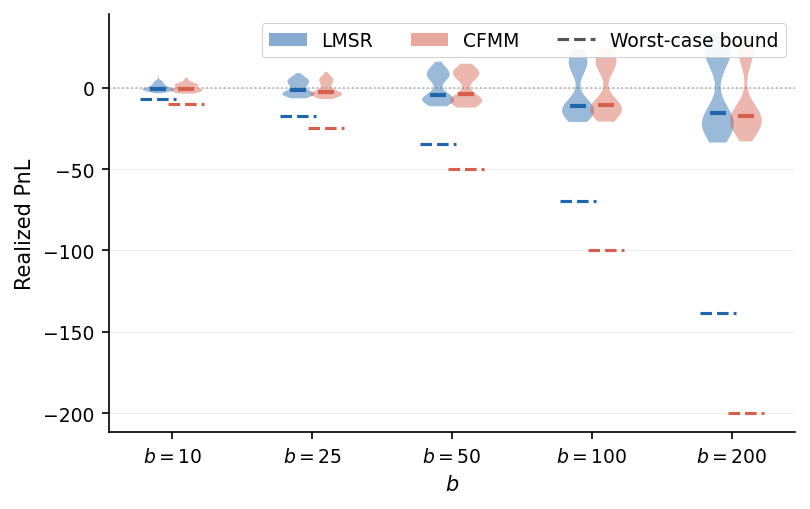

In [10]:
plot_pnl_paired(
    data2, B_VALS,
    tick_labels=[f'$b={b}$' for b in B_VALS],
    x_label='$b$',
    save_name='pnl_vary_b',
)

C:\Users\n8tew\AppData\Local\Temp\ipykernel_11400\1869584543.py:134: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


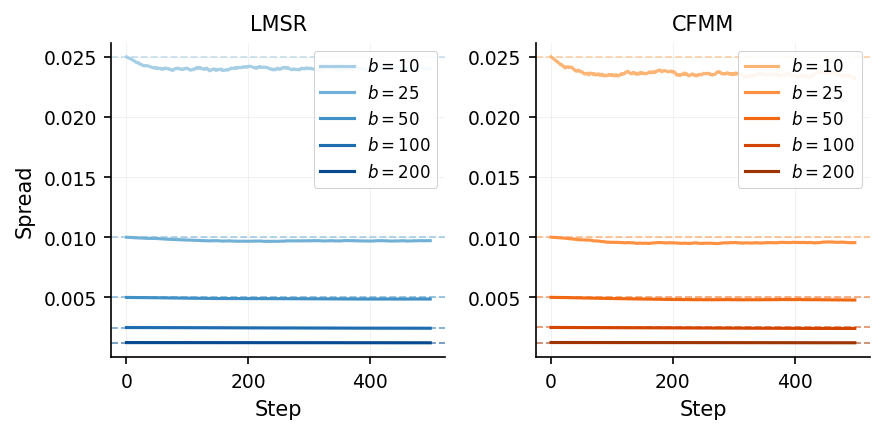

In [11]:
plot_spread_paired(
    data2, B_VALS,
    param_label='b', tick_vals=B_VALS,
    save_name='spread_vary_b',
)

---
## Vary $k$ (CFMM only)

Fix $n=2$, $b=50$ (LMSR unchanged). CFMM bound $= k^{1/2}$ grows with $k$; larger $k$ means more liquidity and smaller spread. $k=2500=50^2$ is the normalized baseline.

In [12]:
K_VALS = [100, 500, 2500, 12500, 62500]
N3, B3 = 2, 50
print('Simulating: vary k')
data3 = run_experiment(
    K_VALS,
    make_lmsr  = lambda k: LMSR(N3, b=B3),
    make_cfmm  = lambda k: CFMM(N3, k_constant=k),
    n_fn       = lambda k: N3,
    lmsr_bound = lambda k: B3 * np.log(N3),
    cfmm_bound = lambda k: k ** (1.0 / N3),
)

Simulating: vary k
  pv=100: LMSR med=-4.6, CFMM med=-0.5,  bounds: LMSR=34.7, CFMM=10.0
  pv=500: LMSR med=-5.4, CFMM med=-2.0,  bounds: LMSR=34.7, CFMM=22.4
  pv=2500: LMSR med=-3.0, CFMM med=-4.8,  bounds: LMSR=34.7, CFMM=50.0
  pv=12500: LMSR med=-5.4, CFMM med=-11.3,  bounds: LMSR=34.7, CFMM=111.8
  pv=62500: LMSR med=-4.5, CFMM med=-19.2,  bounds: LMSR=34.7, CFMM=250.0


C:\Users\n8tew\AppData\Local\Temp\ipykernel_11400\2550645853.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_k = cm.get_cmap('Oranges')


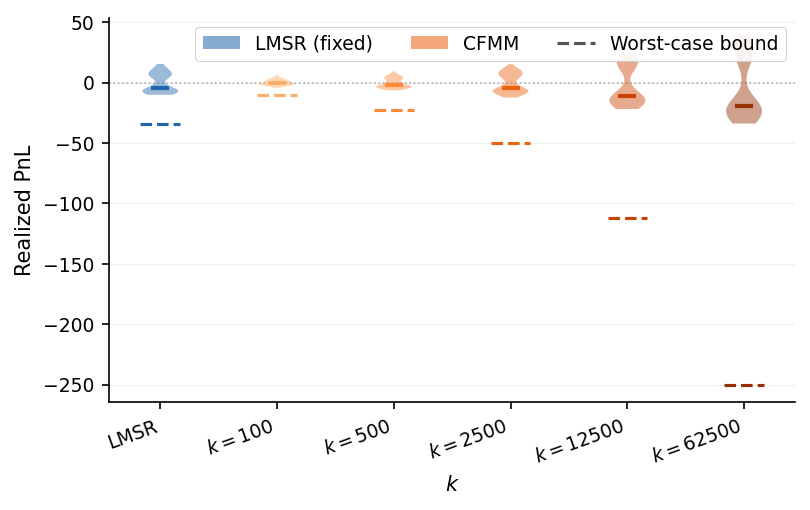

In [13]:
# PnL: LMSR reference violin on left, CFMM violin per k on right
fig, ax = plt.subplots(figsize=(5.5, 3.5))

hw = 0.22
ref = data3[K_VALS[0]]

# LMSR reference (invariant to k)
vl = ax.violinplot([ref['lmsr_pnl']], [0], widths=0.4,
                   showmedians=True, showextrema=False)
_style_violin(vl, C_LMSR)
ax.hlines(-ref['lmsr_bound'], -hw, hw, colors=C_LMSR, ls='--', lw=1.5)

# CFMM per k
cmap_k = cm.get_cmap('Oranges')
shades_k = np.linspace(0.38, 0.92, len(K_VALS))
for i, k in enumerate(K_VALS):
    d = data3[k]
    pos = (i + 1) * 1.3
    c = cmap_k(shades_k[i])
    vc = ax.violinplot([d['cfmm_pnl']], [pos], widths=0.4,
                       showmedians=True, showextrema=False)
    _style_violin(vc, c)
    ax.hlines(-d['cfmm_bound'], pos-hw, pos+hw, colors=c, ls='--', lw=1.5)

ax.axhline(0, color='#aaaaaa', lw=0.8, ls=':', zorder=0)
positions = [0] + [(i+1)*1.3 for i in range(len(K_VALS))]
tick_lbls = ['LMSR'] + [f'$k={k}$' for k in K_VALS]
ax.set_xticks(positions)
ax.set_xticklabels(tick_lbls, rotation=20, ha='right')
ax.set_ylabel('Realized PnL')
ax.set_xlabel('$k$')
ax.grid(True, axis='y', alpha=0.25)

p1 = mpatches.Patch(facecolor=C_LMSR, alpha=0.55, label='LMSR (fixed)')
p2 = mpatches.Patch(facecolor=cmap_k(0.65), alpha=0.55, label='CFMM')
p3 = plt.Line2D([0],[0], color='#555', ls='--', lw=1.5, label='Worst-case bound')
ax.legend(handles=[p1,p2,p3], ncol=3, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('pnl_vary_k.pdf', bbox_inches='tight')
plt.savefig('pnl_vary_k.png', bbox_inches='tight')
plt.show()

C:\Users\n8tew\AppData\Local\Temp\ipykernel_11400\2634010855.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_k = cm.get_cmap('Oranges')


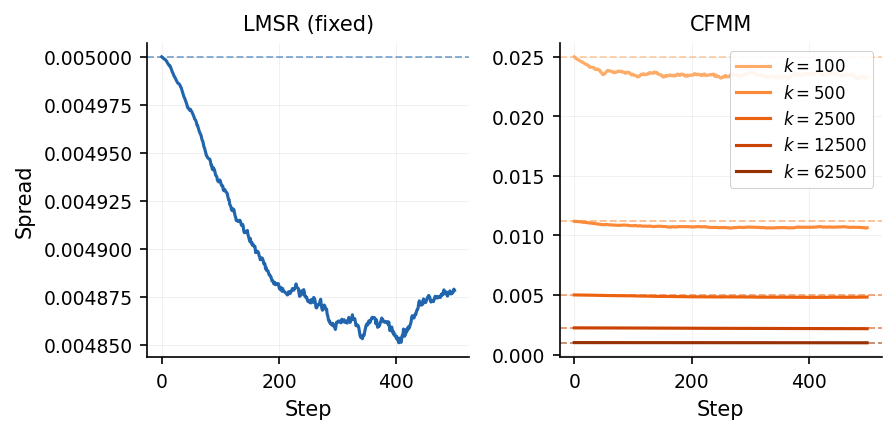

In [14]:
# Spread: LMSR panel (single fixed line), CFMM panel (one line per k)
fig, axes = plt.subplots(1, 2, figsize=(6.0, 3.0))
t_axis = np.arange(T)
cmap_k = cm.get_cmap('Oranges')
shades_k = np.linspace(0.38, 0.92, len(K_VALS))

# Left: LMSR (invariant to k — show once)
ax = axes[0]
ms = data3[K_VALS[0]]['lmsr_sp'].mean(axis=0)
sp0 = data3[K_VALS[0]]['lmsr_sp0']
ax.plot(t_axis, ms, color=C_LMSR, lw=1.5)
ax.axhline(sp0, color=C_LMSR, ls='--', lw=0.9, alpha=0.55)
ax.set_xlabel('Step')
ax.set_ylabel('Spread')
ax.set_title('LMSR (fixed)')
ax.grid(True, alpha=0.2)

# Right: CFMM per k
ax = axes[1]
for i, k in enumerate(K_VALS):
    d = data3[k]
    ms = d['cfmm_sp'].mean(axis=0)
    c  = cmap_k(shades_k[i])
    ax.plot(t_axis, ms, color=c, lw=1.5, label=f'$k={k}$')
    ax.axhline(d['cfmm_sp0'], color=c, ls='--', lw=0.9, alpha=0.55)
ax.set_xlabel('Step')
ax.set_title('CFMM')
ax.legend(fontsize=8, ncol=1, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('spread_vary_k.pdf', bbox_inches='tight')
plt.savefig('spread_vary_k.png', bbox_inches='tight')
plt.show()